In [1]:
!pip install -q transformers torch pillow matplotlib

In [2]:
import torch
from PIL import Image
import requests
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel

In [3]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

(np.float64(-0.5), np.float64(7374.5), np.float64(4918.5), np.float64(-0.5))

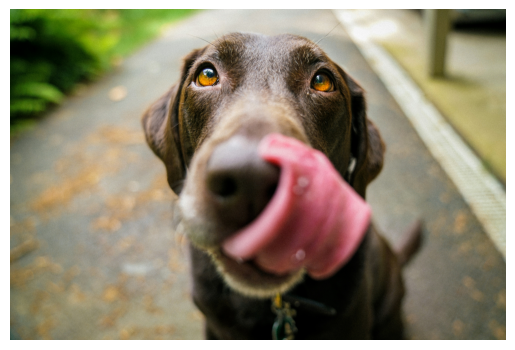

In [6]:
url = "https://images.unsplash.com/photo-1518717758536-85ae29035b6d"

image = Image.open(requests.get(url, stream=True).raw)

plt.imshow(image)
plt.axis("off")

In [7]:
candidate_captions = [
    "A dog running in a field",
    "A cat sitting on a sofa",
    "A car parked on the road",
    "A dog playing outside",
    "A group of people walking"
]

In [8]:
inputs = processor(
    text=candidate_captions,
    images=image,
    return_tensors="pt",
    padding=True
)

In [9]:
outputs = model(**inputs)

logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

In [10]:
best_caption_index = probs.argmax().item()

best_caption = candidate_captions[best_caption_index]

print("Predicted Caption:", best_caption)

Predicted Caption: A dog playing outside


In [11]:
for caption, prob in zip(candidate_captions, probs[0]):
    print(f"{caption} : {prob.item():.4f}")

A dog running in a field : 0.0582
A cat sitting on a sofa : 0.0000
A car parked on the road : 0.0008
A dog playing outside : 0.9409
A group of people walking : 0.0001
